# Electricity Regime-Conditional Robustness and Temporal Stability

## Role
This notebook tests whether model quality remains stable once the aggregate accuracy
ranking is conditioned on demand regimes, volatility regimes, forecasting protocol, and
chronological test segment -- rather than only looking good in aggregate.

## Inputs
- `results/electricity/protocol_a_validated_forecasts.csv`
- `results/electricity/protocol_b_validated_forecasts.csv`
- `results/electricity/protocol_a_robustness.csv`
- `results/electricity/protocol_b_robustness.csv`
- `results/electricity/protocol_a_generalisation.csv`
- `results/electricity/protocol_b_generalisation.csv`

## Outputs
Regime-conditional model evidence, robustness rankings, temporal-stability evidence,
cross-protocol robustness diagnostics, rank-reversal evidence, and local validation
checks. It does NOT create new forecast evidence.

## Depends On
`14_Electricity_Model_Validation_Audit.ipynb`

## Authoritative Status
`AUTHORITATIVE REGIME-CONDITIONAL ROBUSTNESS AND TEMPORAL STABILITY EVIDENCE`

## What This Notebook Does Not Do
This notebook does NOT:
- train any model or regenerate any forecast
- perform uncertainty calibration (`16_Electricity_Uncertainty.ipynb`)
- compute Trust Scores (`17_Electricity_Trustworthiness.ipynb`)
- perform statistical-significance testing (`18_Electricity_Statistical_Significance.ipynb`)
- offer a causal explanation of why a model performs worse in any regime
- make a universal robustness claim beyond this frozen series, period, and regime set

## 1. Objective and Research Questions

> Do models that perform well on aggregate Electricity accuracy retain their advantage
> when evaluated under specific demand, volatility, protocol, and temporal conditions?

### Q1 — Regime Robustness
Which models maintain low error across Low Demand, High Demand, Peak Demand, and High
Volatility conditions?

### Q2 — Worst-Case Behavior
Which models fail most sharply in their hardest regime?

### Q3 — Protocol Sensitivity
Does a model that appears robust under rolling one-step forecasting remain robust under
true day-ahead forecasting?

### Q4 — Temporal Stability
Is model performance consistent across Earlier, Middle, and Later portions of the frozen
test period?

### Q5 — Ranking Stability
Do aggregate accuracy rankings agree with robustness and Temporal Stability rankings, or
do meaningful rank reversals occur?

Robustness is treated throughout as a **distinct evidence dimension**, not a synonym for
aggregate accuracy -- a model can rank well in one and poorly in the other, and both
statements can be simultaneously true and useful.

## 2. Setup

Only the frozen forecast matrices and the frozen regime/temporal-segment metrics
artifacts are loaded. No model is fit, no forecast is regenerated, and no authoritative
artifact is written.

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate project root containing src/")

ROOT = find_project_root(Path.cwd())
R = ROOT / "results/electricity"
SCALE = 117.057971280678

pa = pd.read_csv(R / "protocol_a_validated_forecasts.csv", parse_dates=["Timestamp"])
pb = pd.read_csv(R / "protocol_b_validated_forecasts.csv", parse_dates=["Origin", "Timestamp"])
MODELS = ["Naive", "Daily_Seasonal_Naive", "Weekly_Seasonal_Naive", "Moving_Average", "ARIMA", "SARIMA",
          "Prophet", "Simple_Exponential_Smoothing", "Holt_Winters", "DHR_ARIMA", "LSTM", "Chronos_Bolt_Tiny", "TimesFM"]
assert pa.shape == (46176, 15) and pb.shape == (46176, 17)
assert len(MODELS) == 13

robust_a = pd.read_csv(R / "protocol_a_robustness.csv")
robust_b = pd.read_csv(R / "protocol_b_robustness.csv")
temporal_a = pd.read_csv(R / "protocol_a_generalisation.csv", parse_dates=["Start", "End"])
temporal_b = pd.read_csv(R / "protocol_b_generalisation.csv", parse_dates=["Start", "End"])

### Notebook-Local Helper Functions

Small, reusable helpers to avoid repeating the same pivot/ranking/diagnostic logic across
Protocol A and Protocol B (Sections 5-9). None of these fit a model, alter a forecast, or
write a file -- each operates only on the already-loaded frozen artifacts above.

In [2]:
# Long-form (Model, condition) evidence -> wide Model x condition matrix.
def pivot_regime(long_df, condition_col, value_col="MASE_48"):
    return long_df.pivot(index="Model", columns=condition_col, values=value_col)

# Series indexed by Model -> DataFrame with an integer Rank column, best = 1.
def make_rank(penalty_series, ascending=True):
    ordered = penalty_series.sort_values(ascending=ascending)
    return pd.DataFrame({penalty_series.name: ordered, "Rank": np.arange(1, len(ordered) + 1)}, index=ordered.index)

# Model x condition matrix -> mean, std, and Penalty = mean + std, sorted by Penalty.
def penalty_from_matrix(matrix):
    out = matrix.agg(["mean", "std"], axis=1)
    out["Penalty"] = out["mean"] + out["std"]
    return out.sort_values("Penalty")

# Model x condition matrix -> best/worst condition, values, and range per model.
def worst_condition(matrix):
    rows = []
    for model, row in matrix.iterrows():
        best_c, worst_c = row.idxmin(), row.idxmax()
        rows.append({"Model": model, "Best Condition": best_c, "Best MASE-48": row[best_c],
                     "Worst Condition": worst_c, "Worst MASE-48": row[worst_c], "Range": row[worst_c] - row[best_c]})
    return pd.DataFrame(rows).set_index("Model")

# Two Rank series indexed by Model -> comparison table with signed and absolute change.
def rank_change(rank_a, rank_b, label_a, label_b):
    out = pd.DataFrame({label_a: rank_a, label_b: rank_b})
    out["Change"] = out[label_b] - out[label_a]
    out["Absolute Change"] = out["Change"].abs()
    return out.sort_values("Absolute Change", ascending=False)

def make_audit_row(category, check, expected, observed, result):
    return {"Category": category, "Check": check, "Expected": expected, "Observed": observed, "Result": result}

# 3. Evidence Boundary and Method

## 3.1 Frozen Forecast Evidence

All robustness and temporal analysis below is derived from forecast vectors already
certified in `14_Electricity_Model_Validation_Audit.ipynb`. No model is rerun here. This
creates a clean evidence boundary:

> forecast generation -> artifact validation -> conditional evaluation

This notebook performs only the last step.

## 3.2 Regime Definitions

Four demand/volatility regimes are evaluated under Protocol A (**Low Demand**, **High
Demand**, **Peak Demand Event**, **High Volatility**), and four analogous whole-day
regimes under Protocol B (**Low Demand Days**, **High Demand Days**, **Peak Demand
Days**, **High Volatility Days**). Each threshold is a frozen numeric cut-off computed
once from pre-test data and then applied unchanged to the frozen test observations -- no
threshold is derived from, or adjusted using, any model's forecast error. Protocol A's
volatility measure is a 48-half-hourly-change window (`ddof=0`), shifted one step so it is
past-observable at forecast time; Protocol B's regimes are retrospective whole-day
labels. Both use pre-test data only to set the threshold values (Section 4.1).

The exact statistic/percentile rule that produced each frozen numeric threshold is not
further decomposed within this notebook's own code or its source -- only the resulting
frozen threshold values are available as evidence (Section 4.1). This is stated
explicitly (`Frozen pre-test-derived threshold; exact percentile derivation not
preserved`) rather than assuming a specific derivation rule that cannot be verified
(Section 13, Limitations).

## 3.3 Temporal Segmentation

The frozen test period is divided chronologically into three **Temporal Stability**
segments -- **Earlier**, **Middle**, **Later** -- evaluated separately for both
protocols. Roughly balanced segments make it possible to tell whether aggregate
performance is being driven disproportionately by one part of the test period rather
than holding consistently across it. The underlying stored artifact columns retain the
historical `generalisation` filename/terminology; this notebook uses **Temporal
Stability** throughout its own prose and labels.

## 3.4 Robustness Metric

```
Robustness Penalty = mean(regime MASE-48) + std(regime MASE-48)
```

Lower is better.

In [3]:
metric_definition_robustness = pd.DataFrame([
    {"Component": "Mean regime MASE-48", "Interpretation": "Overall conditional error level across regimes"},
    {"Component": "Std regime MASE-48", "Interpretation": "Variability across regimes (spread of conditional performance)"},
    {"Component": "Mean + Std", "Interpretation": "Current exploratory Robustness Penalty (lower is better)"},
])
display(metric_definition_robustness)

,Component,Interpretation
0,Mean regime MASE-48,Overall conditional error level across regimes
1,Std regime MASE-48,Variability across regimes (spread of conditio...
2,Mean + Std,Current exploratory Robustness Penalty (lower ...


This is an **operational summary / project-defined robustness penalty**, not a
universally validated robustness metric -- it is one reasonable way to combine
conditional-error level and conditional-error spread into a single ranking number, not
the only possible way.

## 3.5 Temporal Stability Metric

```
Temporal Stability Penalty = mean(Earlier/Middle/Later MASE-48) + std(across the three segments)
```

Lower is better.

In [4]:
metric_definition_temporal = pd.DataFrame([
    {"Component": "Mean segment MASE-48", "Interpretation": "Overall error level across Earlier/Middle/Later"},
    {"Component": "Std segment MASE-48", "Interpretation": "Variability across the three chronological segments"},
    {"Component": "Mean + Std", "Interpretation": "Current exploratory Temporal Stability Penalty (lower is better)"},
])
display(metric_definition_temporal)

,Component,Interpretation
0,Mean segment MASE-48,Overall error level across Earlier/Middle/Later
1,Std segment MASE-48,Variability across the three chronological seg...
2,Mean + Std,Current exploratory Temporal Stability Penalty...


As with the Robustness Penalty, this is a **project-defined summary**, not a validated
universal instrument -- and it is estimated from only three data points per model per
protocol (Section 13, Limitations).

## 3.6 Interpretation Rules

- Lower MASE-48 means better conditional accuracy.
- Lower Robustness Penalty means a better current robustness summary (Section 3.4).
- Lower Temporal Stability Penalty means a more favourable current temporal summary
  (Section 3.5).
- A smaller regime/segment spread means more stable conditional behaviour, independent of
  the absolute error level.
- Sample size matters when interpreting regime metrics -- a penalty computed over a
  small regime carries more sampling uncertainty than a same-scale bar chart visually
  implies (Section 4.2).
- Robustness rank is **not** identical to aggregate accuracy rank; Sections 5.5 and 6.5
  measure the difference directly rather than assuming either equivalence or divergence.

# 4. Regime Composition

## 4.1 Frozen Thresholds — Table

The thresholds below are frozen numeric cut-offs estimated once from pre-test data and
held fixed during evaluation (Section 3.2). They are centralized here in a single
`FROZEN_REGIME_THRESHOLDS` structure rather than scattered through the notebook, and are
not presented as newly recomputed.

In [5]:
FROZEN_REGIME_THRESHOLDS = {
    "High_Demand": 1670.4041578000001, "Low_Demand": 946.0465484, "Peak_Demand_Event": 2232.6494689999995,
    "High_Volatility_48": 65.57585557297838, "Low_Demand_Day_Mean": 1066.5905699375,
    "High_Demand_Day_Mean": 1543.2729856666665, "High_Volatility_Day": 65.50342414296712,
}

threshold_table = pd.DataFrame([
    {"Regime": "High Demand", "Protocol": "A", "Conditioning Variable": "Demand level", "Frozen Threshold": FROZEN_REGIME_THRESHOLDS["High_Demand"], "Direction": ">= threshold", "Threshold Source": "Frozen pre-test-derived threshold; exact percentile derivation not preserved"},
    {"Regime": "Low Demand", "Protocol": "A", "Conditioning Variable": "Demand level", "Frozen Threshold": FROZEN_REGIME_THRESHOLDS["Low_Demand"], "Direction": "<= threshold", "Threshold Source": "Frozen pre-test-derived threshold; exact percentile derivation not preserved"},
    {"Regime": "Peak Demand Event", "Protocol": "A", "Conditioning Variable": "Demand level", "Frozen Threshold": FROZEN_REGIME_THRESHOLDS["Peak_Demand_Event"], "Direction": ">= threshold", "Threshold Source": "Frozen pre-test-derived threshold; exact percentile derivation not preserved"},
    {"Regime": "High Volatility", "Protocol": "A", "Conditioning Variable": "48-step change volatility", "Frozen Threshold": FROZEN_REGIME_THRESHOLDS["High_Volatility_48"], "Direction": ">= threshold", "Threshold Source": "Frozen pre-test-derived threshold; exact percentile derivation not preserved"},
    {"Regime": "Low Demand Days", "Protocol": "B", "Conditioning Variable": "Daily mean demand level", "Frozen Threshold": FROZEN_REGIME_THRESHOLDS["Low_Demand_Day_Mean"], "Direction": "<= threshold", "Threshold Source": "Frozen pre-test-derived threshold; exact percentile derivation not preserved"},
    {"Regime": "High Demand Days", "Protocol": "B", "Conditioning Variable": "Daily mean demand level", "Frozen Threshold": FROZEN_REGIME_THRESHOLDS["High_Demand_Day_Mean"], "Direction": ">= threshold", "Threshold Source": "Frozen pre-test-derived threshold; exact percentile derivation not preserved"},
    {"Regime": "High Volatility Days", "Protocol": "B", "Conditioning Variable": "Daily volatility", "Frozen Threshold": FROZEN_REGIME_THRESHOLDS["High_Volatility_Day"], "Direction": ">= threshold", "Threshold Source": "Frozen pre-test-derived threshold; exact percentile derivation not preserved"},
])
display(threshold_table)

,Regime,Protocol,Conditioning Variable,Frozen Threshold,Direction,Threshold Source
0,High Demand,A,Demand level,1670.404158,>= threshold,Frozen pre-test-derived threshold; exact perce...
1,Low Demand,A,Demand level,946.046548,<= threshold,Frozen pre-test-derived threshold; exact perce...
2,Peak Demand Event,A,Demand level,2232.649469,>= threshold,Frozen pre-test-derived threshold; exact perce...
3,High Volatility,A,48-step change volatility,65.575856,>= threshold,Frozen pre-test-derived threshold; exact perce...
4,Low Demand Days,B,Daily mean demand level,1066.590570,<= threshold,Frozen pre-test-derived threshold; exact perce...
5,High Demand Days,B,Daily mean demand level,1543.272986,>= threshold,Frozen pre-test-derived threshold; exact perce...
6,High Volatility Days,B,Daily volatility,65.503424,>= threshold,Frozen pre-test-derived threshold; exact perce...


`Peak Demand Days` (Protocol B) shares the same demand-level conditioning as `High
Demand Days` at a more extreme cut-off, using `Peak_Demand_Event`'s underlying frozen
definition; no separate `Peak_Demand_Day` threshold is stored in the frozen artifact
beyond what is already listed above. Volatility window: 48 half-hourly changes, `ddof=0`.
Protocol A's measure is shifted one step and past-observable. Protocol B's regimes are
retrospective whole-day labels. All thresholds use pre-test data only.

## 4.2 Regime Sample Sizes — Table

Computed directly from the frozen robustness artifacts (constant across models within a
regime, since regime membership is a property of the time period, not of any model).

In [6]:
sample_a = robust_a.groupby("Regime").N.first().rename("N")
sample_a_table = sample_a.to_frame()
sample_a_table["Share (%)"] = 100 * sample_a_table.N / len(pa)
sample_a_table["Unit"] = "half-hourly observations"
sample_a_table.insert(0, "Protocol", "A")

sample_b = robust_b.groupby("Regime")[["Days", "Forecast_Points"]].first()
sample_b_table = sample_b.rename(columns={"Days": "N"})[["N"]]
sample_b_table["Share (%)"] = 100 * sample_b_table.N / pb.Origin.nunique()
sample_b_table["Unit"] = "days"
sample_b_table.insert(0, "Protocol", "B")

regime_sample_sizes = pd.concat([sample_a_table.reset_index(), sample_b_table.reset_index()], ignore_index=True)
display(regime_sample_sizes[["Protocol", "Regime", "N", "Share (%)", "Unit"]])

,Protocol,Regime,N,Share (%),Unit
0,A,High Demand,3081,6.672297,half-hourly observations
1,A,High Volatility,10217,22.126213,half-hourly observations
2,A,Low Demand,9121,19.752685,half-hourly observations
3,A,Peak Demand Event,459,0.994023,half-hourly observations
4,B,High Demand Days,50,5.197505,days
5,B,High Volatility Days,210,21.829522,days
6,B,Low Demand Days,226,23.492723,days
7,B,Peak Demand Days,38,3.950104,days


### 4.3 Regime Composition — Visualization

Protocol A counts (half-hourly observations) and Protocol B counts (days) are shown as
separate panels because their units differ and are not directly comparable on one axis.

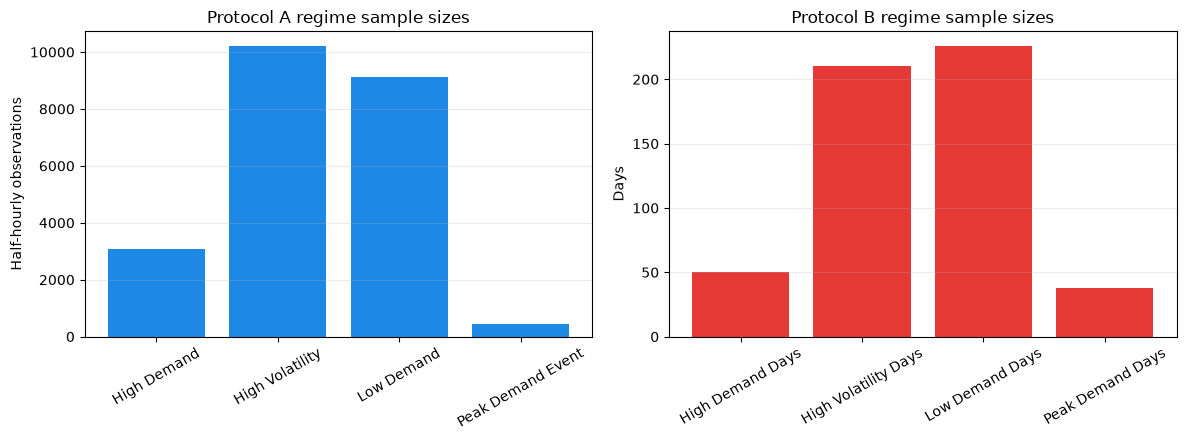

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
a_rows = regime_sample_sizes[regime_sample_sizes.Protocol == "A"]
b_rows = regime_sample_sizes[regime_sample_sizes.Protocol == "B"]
axs[0].bar(a_rows.Regime, a_rows.N, color="#1e88e5")
axs[0].set(title="Protocol A regime sample sizes", ylabel="Half-hourly observations")
axs[1].bar(b_rows.Regime, b_rows.N, color="#e53935")
axs[1].set(title="Protocol B regime sample sizes", ylabel="Days")
for ax in axs:
    ax.tick_params(axis="x", rotation=30); ax.grid(axis="y", alpha=0.25)
fig.tight_layout(); plt.show()

Regime sizes are visibly unequal under both protocols -- `Peak Demand Event` (Protocol A)
and `Peak Demand Days` (Protocol B) are the smallest regimes by a wide margin. Smaller
regimes imply greater sampling uncertainty in the conditional point estimates that
follow (Sections 5-6); this is stated before any performance table is shown so it can be
kept in mind while reading them, not discovered only in the Limitations section.

# 5. Protocol A — Regime-Conditional Robustness

## 5.1 Full Conditional Performance Table

The long-form `protocol_a_robustness.csv` artifact (displayed in full below) is pivoted
into a research-friendly Model x Regime matrix; the long-form artifact itself is not
removed.

In [8]:
display(robust_a)

matrix_a = pivot_regime(robust_a, "Regime")
penalty_a = penalty_from_matrix(matrix_a)
robustness_table_a = matrix_a.loc[penalty_a.index].join(penalty_a).rename(columns={"mean": "Mean", "std": "Std", "Penalty": "Robustness Penalty"})
robustness_table_a.insert(0, "Rank", np.arange(1, len(robustness_table_a) + 1))
display(robustness_table_a)
assert len(robustness_table_a) == 13

,Protocol,Regime,Model,MAE,RMSE,MAPE,sMAPE,MASE_48,N
0,A,Low Demand,Naive,20.526430,26.659410,2.354052,2.341175,0.175353,9121
1,A,Low Demand,Daily_Seasonal_Naive,92.536491,141.863519,10.960927,9.864215,0.790518,9121
2,A,Low Demand,Weekly_Seasonal_Naive,88.003762,167.838193,10.493777,9.105704,0.751796,9121
3,A,Low Demand,Moving_Average,207.145025,236.084678,24.114590,20.934239,1.769593,9121
4,A,Low Demand,DHR_ARIMA,11.509524,16.204498,1.365175,1.349578,0.098323,9121
5,A,Low Demand,LSTM,29.667307,39.146746,3.430021,3.457856,0.253441,9121
6,A,Low Demand,Chronos_Bolt_Tiny,20.184042,25.831610,2.374641,2.412242,0.172428,9121
7,A,Low Demand,TimesFM,9.489844,12.716078,1.108023,1.108894,0.081070,9121
8,A,High Demand,Naive,54.121232,66.512682,2.864932,2.885786,0.462346,3081
9,A,High Demand,Daily_Seasonal_Naive,244.675289,326.642048,12.458357,13.687271,2.090206,3081


,Rank,High Demand,High Volatility,Low Demand,Peak Demand Event,Mean,Std,Robustness Penalty
Model,,,,,,,,
TimesFM,1,0.165121,0.150811,0.081070,0.183991,0.145248,0.044891,0.190140
SARIMA,2,0.205272,0.160777,0.108112,0.225875,0.175009,0.052220,0.227229
DHR_ARIMA,3,0.266976,0.267572,0.098323,0.292841,0.231428,0.089552,0.320980
ARIMA,4,0.279753,0.313507,0.089048,0.211944,0.223563,0.099124,0.322687
Naive,5,0.462346,0.489399,0.175353,0.361230,0.372082,0.142280,0.514362
LSTM,6,0.483869,0.512685,0.253441,0.382604,0.408150,0.117258,0.525408
Chronos_Bolt_Tiny,7,0.474366,0.314809,0.172428,0.584388,0.386498,0.180598,0.567096
Daily_Seasonal_Naive,8,2.090206,1.043088,0.790518,3.014376,1.734547,1.022050,2.756597
Moving_Average,9,3.498272,2.104717,1.769593,5.104828,3.119353,1.520639,4.639991


## 5.2 Regime × Model Heatmap

Models are sorted by Robustness Penalty (best at top) so failure regimes are immediately
visible together with each model's overall robustness position.

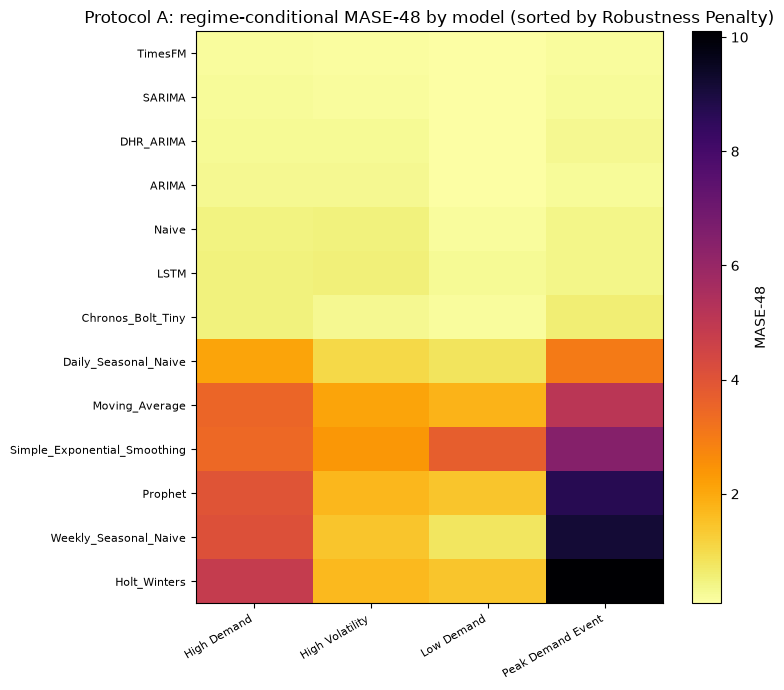

In [9]:
fig, ax = plt.subplots(figsize=(8, 7))
heat_a = matrix_a.loc[penalty_a.index]
im = ax.imshow(heat_a.to_numpy(), aspect="auto", cmap="inferno_r")
ax.set_yticks(range(len(heat_a)), heat_a.index, fontsize=8)
ax.set_xticks(range(len(heat_a.columns)), heat_a.columns, rotation=30, ha="right", fontsize=8)
ax.set(title="Protocol A: regime-conditional MASE-48 by model (sorted by Robustness Penalty)")
fig.colorbar(im, ax=ax, label="MASE-48")
fig.tight_layout(); from pathlib import Path
_figure_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "figures").is_dir())
_figure_dir = _figure_root / "figures" / "electricity"
_figure_dir.mkdir(parents=True, exist_ok=True)
_figure_path = _figure_dir / "electricity_protocol_a_regime_performance.png"
plt.gcf().savefig(_figure_path, dpi=300, bbox_inches="tight")
plt.show()

## 5.3 Robustness Ranking

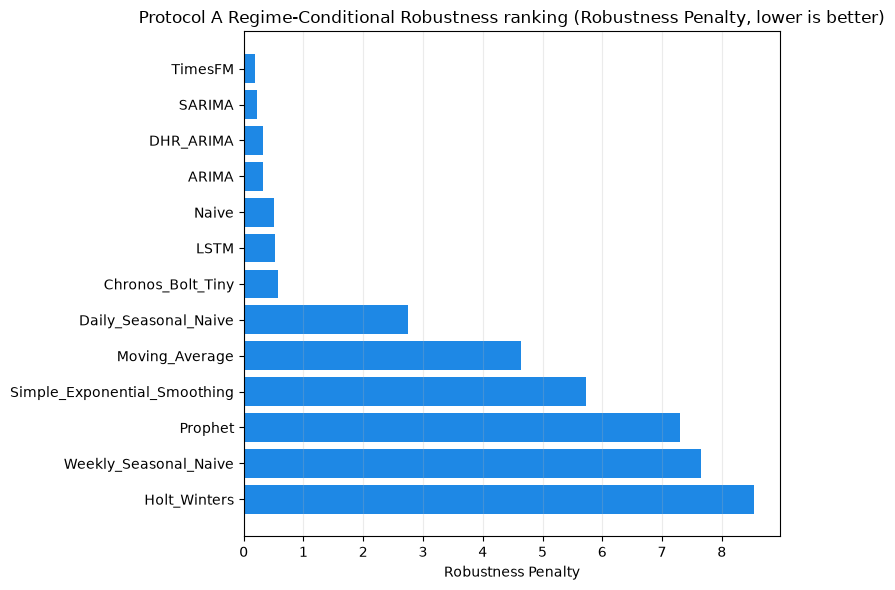

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
order = penalty_a.index[::-1]
ax.barh(order, penalty_a.loc[order, "Penalty"], color="#1e88e5")
ax.set(title="Protocol A Regime-Conditional Robustness ranking (Robustness Penalty, lower is better)", xlabel="Robustness Penalty")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout(); plt.show()

## 5.4 Worst-Regime Diagnostics

Derived evidence only -- this does not redefine the authoritative Robustness Penalty
(Section 3.4/5.1) in any way.

In [11]:
worst_regime_a = worst_condition(matrix_a).loc[penalty_a.index]
display(worst_regime_a)

,Best Condition,Best MASE-48,Worst Condition,Worst MASE-48,Range
Model,,,,,
TimesFM,Low Demand,0.081070,Peak Demand Event,0.183991,0.102921
SARIMA,Low Demand,0.108112,Peak Demand Event,0.225875,0.117763
DHR_ARIMA,Low Demand,0.098323,Peak Demand Event,0.292841,0.194517
ARIMA,Low Demand,0.089048,High Volatility,0.313507,0.224459
Naive,Low Demand,0.175353,High Volatility,0.489399,0.314046
LSTM,Low Demand,0.253441,High Volatility,0.512685,0.259244
Chronos_Bolt_Tiny,Low Demand,0.172428,Peak Demand Event,0.584388,0.411960
Daily_Seasonal_Naive,Low Demand,0.790518,Peak Demand Event,3.014376,2.223857
Moving_Average,Low Demand,1.769593,Peak Demand Event,5.104828,3.335235


## 5.5 Aggregate vs Robustness Rank

Aggregate Protocol A MASE-48 is recomputed directly from the frozen forecast matrix
(`pa`); `Rank Change = Robustness Rank - Aggregate Rank`. Positive means a worse
conditional rank than aggregate; negative means a better robustness rank than aggregate.

In [12]:
aggregate_mase_a = pd.Series({m: np.mean(np.abs(pa.Actual - pa[m])) / SCALE for m in MODELS}, name="MASE_48")
aggregate_rank_a = make_rank(aggregate_mase_a)
robustness_rank_a = make_rank(penalty_a["Penalty"].rename("Robustness_Penalty"))

aggregate_vs_robustness_a = pd.DataFrame({
    "Aggregate Rank": aggregate_rank_a["Rank"], "Aggregate MASE": aggregate_mase_a,
    "Robustness Rank": robustness_rank_a["Rank"], "Robustness Penalty": robustness_rank_a["Robustness_Penalty"],
})
aggregate_vs_robustness_a["Rank Change"] = aggregate_vs_robustness_a["Robustness Rank"] - aggregate_vs_robustness_a["Aggregate Rank"]
aggregate_vs_robustness_a = aggregate_vs_robustness_a.loc[aggregate_rank_a.index]
display(aggregate_vs_robustness_a)

,Aggregate Rank,Aggregate MASE,Robustness Rank,Robustness Penalty,Rank Change
TimesFM,1,0.140002,1,0.190140,0
SARIMA,2,0.146347,2,0.227229,0
DHR_ARIMA,3,0.227636,3,0.320980,0
ARIMA,4,0.246727,4,0.322687,0
Chronos_Bolt_Tiny,5,0.276205,7,0.567096,2
Naive,6,0.361118,5,0.514362,-1
LSTM,7,0.401673,6,0.525408,-1
Daily_Seasonal_Naive,8,1.105573,8,2.756597,0
Weekly_Seasonal_Naive,9,1.308845,12,7.653610,3
Prophet,10,1.513005,11,7.298736,1


A `Rank Change` of 0 means the model's Protocol A conditional robustness position matches
its aggregate-accuracy position exactly; larger magnitudes identify models for which
aggregate accuracy and regime-conditional robustness diverge (Section 9 returns to this
across both protocols and Temporal Stability together).

# 6. Protocol B — Regime-Conditional Robustness

Protocol B operates under a different information set than Protocol A (Section 3.2 of
`11_Electricity_Classical_Baselines.ipynb`); results are not merged with Protocol A's.

## 6.1 Full Conditional Performance Table

In [13]:
display(robust_b)

matrix_b = pivot_regime(robust_b, "Regime")
penalty_b = penalty_from_matrix(matrix_b)
robustness_table_b = matrix_b.loc[penalty_b.index].join(penalty_b).rename(columns={"mean": "Mean", "std": "Std", "Penalty": "Robustness Penalty"})
robustness_table_b.insert(0, "Rank", np.arange(1, len(robustness_table_b) + 1))
display(robustness_table_b)
assert len(robustness_table_b) == 13

,Protocol,Regime,Model,MAE,RMSE,MAPE,sMAPE,MASE_48,Days,Forecast_Points
0,B,Low Demand Days,Naive,294.462989,332.137987,33.460640,27.313123,2.515531,226,10848
1,B,Low Demand Days,Daily_Seasonal_Naive,118.302796,166.500047,12.742984,11.616413,1.010634,226,10848
2,B,Low Demand Days,Weekly_Seasonal_Naive,121.520551,212.447341,12.843795,11.147646,1.038123,226,10848
3,B,Low Demand Days,Moving_Average,174.599878,209.720188,19.204481,17.212438,1.491568,226,10848
4,B,Low Demand Days,DHR_ARIMA,339.779825,373.928718,37.650406,30.406449,2.902663,226,10848
5,B,Low Demand Days,LSTM,206.941674,261.974115,23.243622,19.403112,1.767856,226,10848
6,B,Low Demand Days,Chronos_Bolt_Tiny,136.646976,182.500127,14.942363,13.278011,1.167344,226,10848
7,B,Low Demand Days,TimesFM,76.993491,110.578525,8.366027,7.814254,0.657738,226,10848
8,B,High Demand Days,Naive,409.303741,481.479618,23.058243,23.673022,3.496590,50,2400
9,B,High Demand Days,Daily_Seasonal_Naive,253.352533,349.203419,14.010932,14.926144,2.164334,50,2400


,Rank,High Demand Days,High Volatility Days,Low Demand Days,Peak Demand Days,Mean,Std,Robustness Penalty
Model,,,,,,,,
TimesFM,1,1.578834,0.637132,0.657738,1.694513,1.142054,0.573148,1.715202
SARIMA,2,1.744071,1.045941,0.867210,1.670426,1.331912,0.440528,1.772440
Daily_Seasonal_Naive,3,2.164334,1.046652,1.010634,2.163593,1.596303,0.655642,2.251946
Chronos_Bolt_Tiny,4,2.191512,0.968688,1.167344,2.311273,1.659705,0.689755,2.349459
LSTM,5,2.313020,1.238127,1.767856,2.506424,1.956357,0.571889,2.528246
Moving_Average,6,3.253783,2.068349,1.491568,3.318380,2.533020,0.901264,3.434284
Naive,7,3.496590,2.382829,2.515531,3.734159,3.032277,0.682406,3.714683
Simple_Exponential_Smoothing,8,3.496590,2.382829,2.515531,3.734159,3.032277,0.682406,3.714683
DHR_ARIMA,9,3.355231,2.241685,2.902663,3.799234,3.074703,0.665121,3.739824


## 6.2 Regime × Model Heatmap

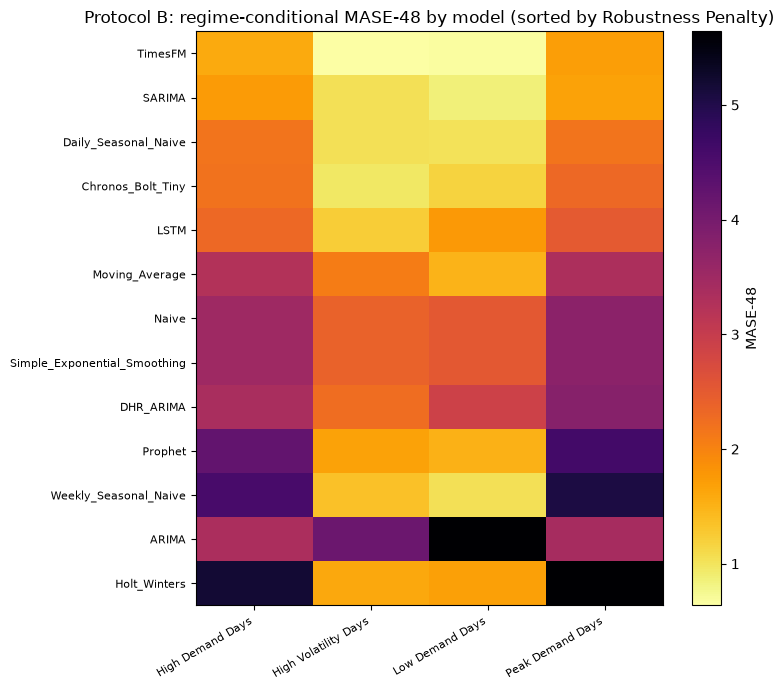

In [14]:
fig, ax = plt.subplots(figsize=(8, 7))
heat_b = matrix_b.loc[penalty_b.index]
im = ax.imshow(heat_b.to_numpy(), aspect="auto", cmap="inferno_r")
ax.set_yticks(range(len(heat_b)), heat_b.index, fontsize=8)
ax.set_xticks(range(len(heat_b.columns)), heat_b.columns, rotation=30, ha="right", fontsize=8)
ax.set(title="Protocol B: regime-conditional MASE-48 by model (sorted by Robustness Penalty)")
fig.colorbar(im, ax=ax, label="MASE-48")
fig.tight_layout(); from pathlib import Path
_figure_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "figures").is_dir())
_figure_dir = _figure_root / "figures" / "electricity"
_figure_dir.mkdir(parents=True, exist_ok=True)
_figure_path = _figure_dir / "electricity_protocol_b_regime_performance.png"
plt.gcf().savefig(_figure_path, dpi=300, bbox_inches="tight")
plt.show()

## 6.3 Robustness Ranking

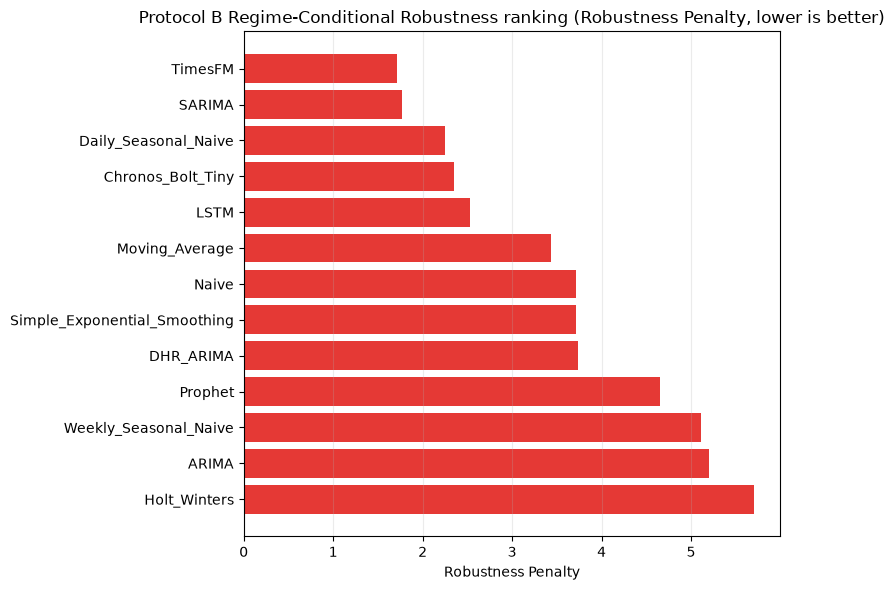

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
order = penalty_b.index[::-1]
ax.barh(order, penalty_b.loc[order, "Penalty"], color="#e53935")
ax.set(title="Protocol B Regime-Conditional Robustness ranking (Robustness Penalty, lower is better)", xlabel="Robustness Penalty")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout(); plt.show()

## 6.4 Worst-Regime Diagnostics

In [16]:
worst_regime_b = worst_condition(matrix_b).loc[penalty_b.index]
display(worst_regime_b)

,Best Condition,Best MASE-48,Worst Condition,Worst MASE-48,Range
Model,,,,,
TimesFM,High Volatility Days,0.637132,Peak Demand Days,1.694513,1.057381
SARIMA,Low Demand Days,0.867210,High Demand Days,1.744071,0.876862
Daily_Seasonal_Naive,Low Demand Days,1.010634,High Demand Days,2.164334,1.153700
Chronos_Bolt_Tiny,High Volatility Days,0.968688,Peak Demand Days,2.311273,1.342585
LSTM,High Volatility Days,1.238127,Peak Demand Days,2.506424,1.268297
Moving_Average,Low Demand Days,1.491568,Peak Demand Days,3.318380,1.826813
Naive,High Volatility Days,2.382829,Peak Demand Days,3.734159,1.351330
Simple_Exponential_Smoothing,High Volatility Days,2.382829,Peak Demand Days,3.734159,1.351330
DHR_ARIMA,High Volatility Days,2.241685,Peak Demand Days,3.799234,1.557549


## 6.5 Aggregate vs Robustness Rank

In [17]:
aggregate_mase_b = pd.Series({m: np.mean(np.abs(pb.Actual - pb[m])) / SCALE for m in MODELS}, name="MASE_48")
aggregate_rank_b = make_rank(aggregate_mase_b)
robustness_rank_b = make_rank(penalty_b["Penalty"].rename("Robustness_Penalty"))

aggregate_vs_robustness_b = pd.DataFrame({
    "Aggregate Rank": aggregate_rank_b["Rank"], "Aggregate MASE": aggregate_mase_b,
    "Robustness Rank": robustness_rank_b["Rank"], "Robustness Penalty": robustness_rank_b["Robustness_Penalty"],
})
aggregate_vs_robustness_b["Rank Change"] = aggregate_vs_robustness_b["Robustness Rank"] - aggregate_vs_robustness_b["Aggregate Rank"]
aggregate_vs_robustness_b = aggregate_vs_robustness_b.loc[aggregate_rank_b.index]
display(aggregate_vs_robustness_b)

,Aggregate Rank,Aggregate MASE,Robustness Rank,Robustness Penalty,Rank Change
TimesFM,1,0.689192,1,1.715202,0
SARIMA,2,1.048901,2,1.772440,0
Chronos_Bolt_Tiny,3,1.077411,4,2.349459,1
Daily_Seasonal_Naive,4,1.105573,3,2.251946,-1
LSTM,5,1.306420,5,2.528246,0
Weekly_Seasonal_Naive,6,1.308845,11,5.106807,5
Prophet,7,1.513005,10,4.653534,3
Holt_Winters,8,1.534479,13,5.708611,5
Moving_Average,9,1.735886,6,3.434284,-3
Simple_Exponential_Smoothing,10,2.083055,8,3.714683,-2


As under Protocol A (Section 5.5), a `Rank Change` of 0 means the conditional and
aggregate positions agree for that model under Protocol B specifically.

# 7. Cross-Protocol Robustness Analysis

## 7.1 Protocol A vs B Robustness Rank

In [18]:
cross_protocol_rank = rank_change(robustness_rank_a["Rank"], robustness_rank_b["Rank"], "Robustness Rank A", "Robustness Rank B").rename(
    columns={"Change": "Rank Difference"})[["Robustness Rank A", "Robustness Rank B", "Rank Difference", "Absolute Change"]]
display(cross_protocol_rank)

,Robustness Rank A,Robustness Rank B,Rank Difference,Absolute Change
Model,,,,
ARIMA,4,12,8,8
DHR_ARIMA,3,9,6,6
Daily_Seasonal_Naive,8,3,-5,5
Chronos_Bolt_Tiny,7,4,-3,3
Moving_Average,9,6,-3,3
Simple_Exponential_Smoothing,10,8,-2,2
Naive,5,7,2,2
Prophet,11,10,-1,1
LSTM,6,5,-1,1


## 7.2 Robustness Penalty Change

In [19]:
penalty_change = pd.DataFrame({
    "Robustness Penalty A": penalty_a["Penalty"], "Robustness Penalty B": penalty_b["Penalty"],
})
penalty_change["B/A Ratio"] = penalty_change["Robustness Penalty B"] / penalty_change["Robustness Penalty A"]
penalty_change = penalty_change.loc[cross_protocol_rank.index]
display(penalty_change)

,Robustness Penalty A,Robustness Penalty B,B/A Ratio
Model,,,
ARIMA,0.322687,5.200761,16.117065
DHR_ARIMA,0.320980,3.739824,11.651283
Daily_Seasonal_Naive,2.756597,2.251946,0.816929
Chronos_Bolt_Tiny,0.567096,2.349459,4.142968
Moving_Average,4.639991,3.434284,0.740149
Simple_Exponential_Smoothing,5.719601,3.714683,0.649465
Naive,0.514362,3.714683,7.221923
Prophet,7.298736,4.653534,0.637581
LSTM,0.525408,2.528246,4.811967


The B/A ratio is descriptive: Protocol A and Protocol B differ operationally (Sections
3.2-3.3 of `11_Electricity_Classical_Baselines.ipynb`), so a large ratio reflects the
protocol's different information set, not a direct causal degradation of the model
itself.

## 7.3 Protocol-Sensitivity Visualization

Only the three largest rank movers are labelled directly on the chart to keep it
readable; every model is still plotted.

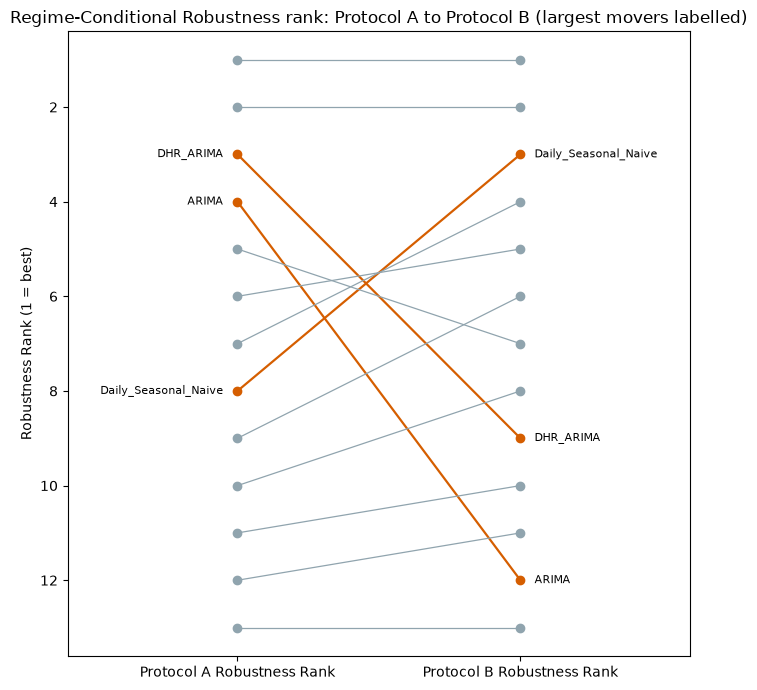

In [20]:
fig, ax = plt.subplots(figsize=(7, 7))
largest_movers = cross_protocol_rank.sort_values("Absolute Change", ascending=False).index[:3]
for model in cross_protocol_rank.index:
    a_rank, b_rank = robustness_rank_a.loc[model, "Rank"], robustness_rank_b.loc[model, "Rank"]
    color = "#D55E00" if model in largest_movers else "#90a4ae"
    ax.plot([0, 1], [a_rank, b_rank], color=color, marker="o", linewidth=1.6 if model in largest_movers else 0.9)
    if model in largest_movers:
        ax.text(-0.05, a_rank, model, ha="right", va="center", fontsize=8)
        ax.text(1.05, b_rank, model, ha="left", va="center", fontsize=8)
ax.set_xlim(-0.6, 1.6); ax.set_xticks([0, 1]); ax.set_xticklabels(["Protocol A Robustness Rank", "Protocol B Robustness Rank"])
ax.invert_yaxis(); ax.set(title="Regime-Conditional Robustness rank: Protocol A to Protocol B (largest movers labelled)", ylabel="Robustness Rank (1 = best)")
plt.tight_layout(); from pathlib import Path
_figure_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "figures").is_dir())
_figure_dir = _figure_root / "figures" / "electricity"
_figure_dir.mkdir(parents=True, exist_ok=True)
_figure_path = _figure_dir / "electricity_robustness_rank_change.png"
plt.gcf().savefig(_figure_path, dpi=300, bbox_inches="tight")
plt.show()

Models whose lines cross steeply are the most protocol-sensitive in their robustness
position; near-horizontal lines indicate a robustness rank that holds regardless of which
protocol is used.

# 8. Temporal Stability

## 8.1 Segment Definition — Table

In [21]:
segment_definition = temporal_a.groupby("Segment")[["N", "Start", "End"]].first()
segment_definition["Share of Test (%)"] = 100 * segment_definition.N / len(pa)
segment_definition = segment_definition.loc[["Earlier", "Middle", "Later"]]
display(segment_definition[["Start", "End", "N", "Share of Test (%)"]])

,Start,End,N,Share of Test (%)
Segment,,,,
Earlier,2012-07-13,2013-05-29 23:30:00,15408,33.367983
Middle,2013-05-30,2014-04-14 23:30:00,15360,33.264033
Later,2014-04-15,2015-03-01 23:30:00,15408,33.367983


## 8.2 Protocol A Segment Performance

In [22]:
display(temporal_a)

segment_matrix_a = pivot_regime(temporal_a, "Segment")[["Earlier", "Middle", "Later"]]
temporal_penalty_a = penalty_from_matrix(segment_matrix_a)
temporal_table_a = segment_matrix_a.loc[temporal_penalty_a.index].join(temporal_penalty_a).rename(
    columns={"mean": "Mean", "std": "Std", "Penalty": "Temporal Stability Penalty"})
temporal_table_a.insert(0, "Rank", np.arange(1, len(temporal_table_a) + 1))
display(temporal_table_a)

,Protocol,Segment,Model,MAE,RMSE,MAPE,sMAPE,MASE_48,N,Start,End
0,A,Earlier,Naive,40.321622,56.162958,3.248735,3.267029,0.344459,15408,2012-07-13,2013-05-29 23:30:00
1,A,Earlier,Daily_Seasonal_Naive,135.765366,209.260315,10.797466,10.586409,1.159813,15408,2012-07-13,2013-05-29 23:30:00
2,A,Earlier,Weekly_Seasonal_Naive,159.060107,267.788216,12.090378,11.782879,1.358815,15408,2012-07-13,2013-05-29 23:30:00
3,A,Earlier,Moving_Average,182.102983,232.950868,15.115385,14.527657,1.555665,15408,2012-07-13,2013-05-29 23:30:00
4,A,Earlier,DHR_ARIMA,25.292857,47.936722,1.988851,2.006973,0.216071,15408,2012-07-13,2013-05-29 23:30:00
5,A,Earlier,LSTM,45.438075,69.590674,3.729597,3.701306,0.388167,15408,2012-07-13,2013-05-29 23:30:00
6,A,Earlier,Chronos_Bolt_Tiny,32.200382,45.381491,2.542392,2.553516,0.275081,15408,2012-07-13,2013-05-29 23:30:00
7,A,Earlier,TimesFM,15.640730,25.303114,1.255234,1.263201,0.133615,15408,2012-07-13,2013-05-29 23:30:00
8,A,Middle,Naive,42.457900,58.633382,3.488750,3.510448,0.362708,15360,2013-05-30,2014-04-14 23:30:00
9,A,Middle,Daily_Seasonal_Naive,131.057104,206.112457,10.761522,10.601844,1.119591,15360,2013-05-30,2014-04-14 23:30:00


,Rank,Earlier,Middle,Later,Mean,Std,Temporal Stability Penalty
Model,,,,,,,
TimesFM,1,0.133615,0.141237,0.145156,0.140003,0.005869,0.145871
SARIMA,2,0.141551,0.147019,0.150474,0.146348,0.004499,0.150847
DHR_ARIMA,3,0.216071,0.230566,0.236281,0.227639,0.010418,0.238057
ARIMA,4,0.236011,0.248551,0.255624,0.246729,0.009933,0.256662
Chronos_Bolt_Tiny,5,0.275081,0.272675,0.280849,0.276201,0.004201,0.280402
Naive,6,0.344459,0.362708,0.376193,0.361120,0.015927,0.377047
LSTM,7,0.388167,0.407498,0.409373,0.401679,0.011739,0.413419
Daily_Seasonal_Naive,8,1.159813,1.119591,1.037359,1.105588,0.062416,1.168004
Weekly_Seasonal_Naive,9,1.358815,1.451171,1.116993,1.308993,0.172570,1.481563


## 8.3 Protocol B Segment Performance

In [23]:
display(temporal_b)

segment_matrix_b = pivot_regime(temporal_b, "Segment")[["Earlier", "Middle", "Later"]]
temporal_penalty_b = penalty_from_matrix(segment_matrix_b)
temporal_table_b = segment_matrix_b.loc[temporal_penalty_b.index].join(temporal_penalty_b).rename(
    columns={"mean": "Mean", "std": "Std", "Penalty": "Temporal Stability Penalty"})
temporal_table_b.insert(0, "Rank", np.arange(1, len(temporal_table_b) + 1))
display(temporal_table_b)

,Protocol,Segment,Model,MAE,RMSE,MAPE,sMAPE,MASE_48,N,Days,Start,End
0,B,Earlier,Naive,233.140211,292.980895,20.992461,18.476933,1.991665,15408,321,2012-07-13,2013-05-29 23:30:00
1,B,Earlier,Daily_Seasonal_Naive,135.765366,209.260315,10.797466,10.586409,1.159813,15408,321,2012-07-13,2013-05-29 23:30:00
2,B,Earlier,Weekly_Seasonal_Naive,159.060107,267.788216,12.090378,11.782879,1.358815,15408,321,2012-07-13,2013-05-29 23:30:00
3,B,Earlier,Moving_Average,209.355608,269.523074,17.808623,16.483085,1.788478,15408,321,2012-07-13,2013-05-29 23:30:00
4,B,Earlier,DHR_ARIMA,265.685097,304.574259,23.447309,20.679581,2.269688,15408,321,2012-07-13,2013-05-29 23:30:00
5,B,Earlier,LSTM,143.898372,199.610479,12.084884,11.217647,1.229292,15408,321,2012-07-13,2013-05-29 23:30:00
6,B,Earlier,Chronos_Bolt_Tiny,131.219180,200.342847,10.593631,10.038430,1.120976,15408,321,2012-07-13,2013-05-29 23:30:00
7,B,Earlier,TimesFM,82.996622,130.567222,6.452866,6.356554,0.709022,15408,321,2012-07-13,2013-05-29 23:30:00
8,B,Middle,Naive,244.121682,302.894381,22.889872,19.744343,2.085477,15360,320,2013-05-30,2014-04-14 23:30:00
9,B,Middle,Daily_Seasonal_Naive,131.057104,206.112457,10.761522,10.601844,1.119591,15360,320,2013-05-30,2014-04-14 23:30:00


,Rank,Earlier,Middle,Later,Mean,Std,Temporal Stability Penalty
Model,,,,,,,
TimesFM,1,0.709022,0.670647,0.687849,0.689172,0.019221,0.708394
SARIMA,2,1.099309,1.049748,0.997650,1.048902,0.050835,1.099737
Chronos_Bolt_Tiny,3,1.120976,1.080113,1.031152,1.077414,0.044973,1.122387
Daily_Seasonal_Naive,4,1.159813,1.119591,1.037359,1.105588,0.062416,1.168004
LSTM,5,1.229292,1.337321,1.352742,1.306452,0.067266,1.373718
Weekly_Seasonal_Naive,6,1.358815,1.451171,1.116993,1.308993,0.172570,1.481563
Prophet,7,1.594628,1.577568,1.367020,1.513072,0.126772,1.639844
Holt_Winters,8,1.652290,1.550522,1.400673,1.534495,0.126572,1.661067
Moving_Average,9,1.788478,1.735313,1.683865,1.735885,0.052309,1.788194


## 8.4 Temporal Stability Rankings

Reported as two separate ranked bar charts, not one grouped chart, so each protocol's
ranking is legible on its own.

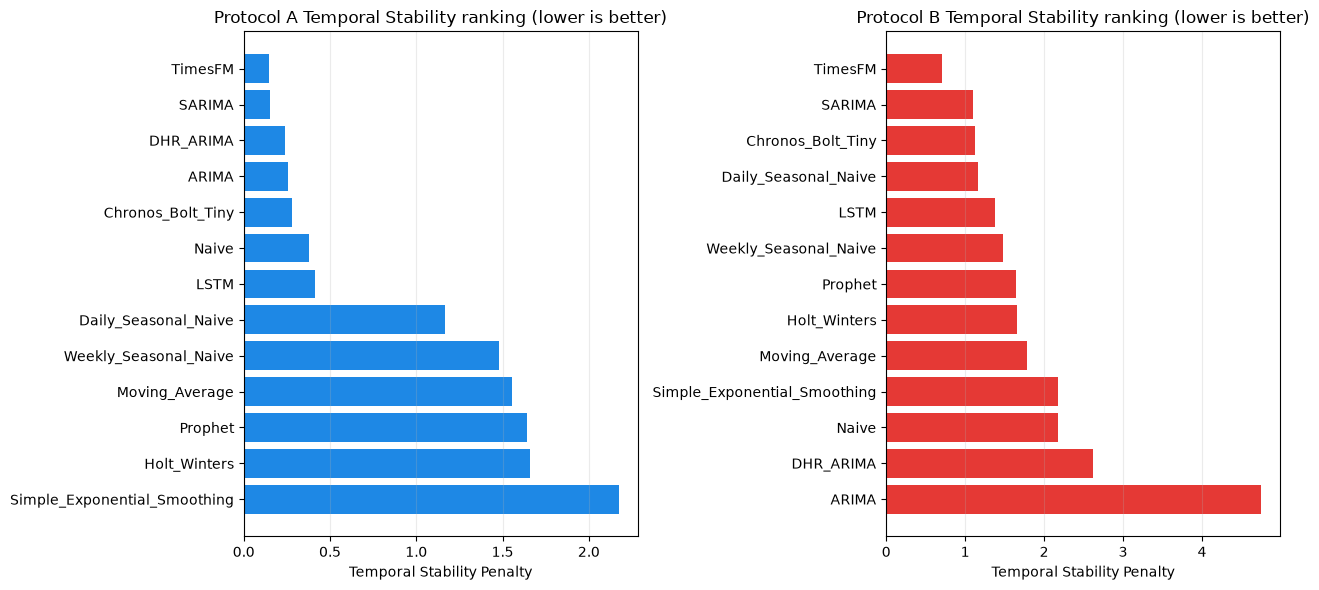

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(13, 6))
order_a = temporal_penalty_a.index[::-1]; order_b = temporal_penalty_b.index[::-1]
axs[0].barh(order_a, temporal_penalty_a.loc[order_a, "Penalty"], color="#1e88e5")
axs[0].set(title="Protocol A Temporal Stability ranking (lower is better)", xlabel="Temporal Stability Penalty")
axs[1].barh(order_b, temporal_penalty_b.loc[order_b, "Penalty"], color="#e53935")
axs[1].set(title="Protocol B Temporal Stability ranking (lower is better)", xlabel="Temporal Stability Penalty")
for ax in axs:
    ax.grid(axis="x", alpha=0.25)
fig.tight_layout(); from pathlib import Path
_figure_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "figures").is_dir())
_figure_dir = _figure_root / "figures" / "electricity"
_figure_dir.mkdir(parents=True, exist_ok=True)
_figure_path = _figure_dir / "electricity_temporal_stability_ranking.png"
plt.gcf().savefig(_figure_path, dpi=300, bbox_inches="tight")
plt.show()

## 8.5 Temporal Performance Visualization

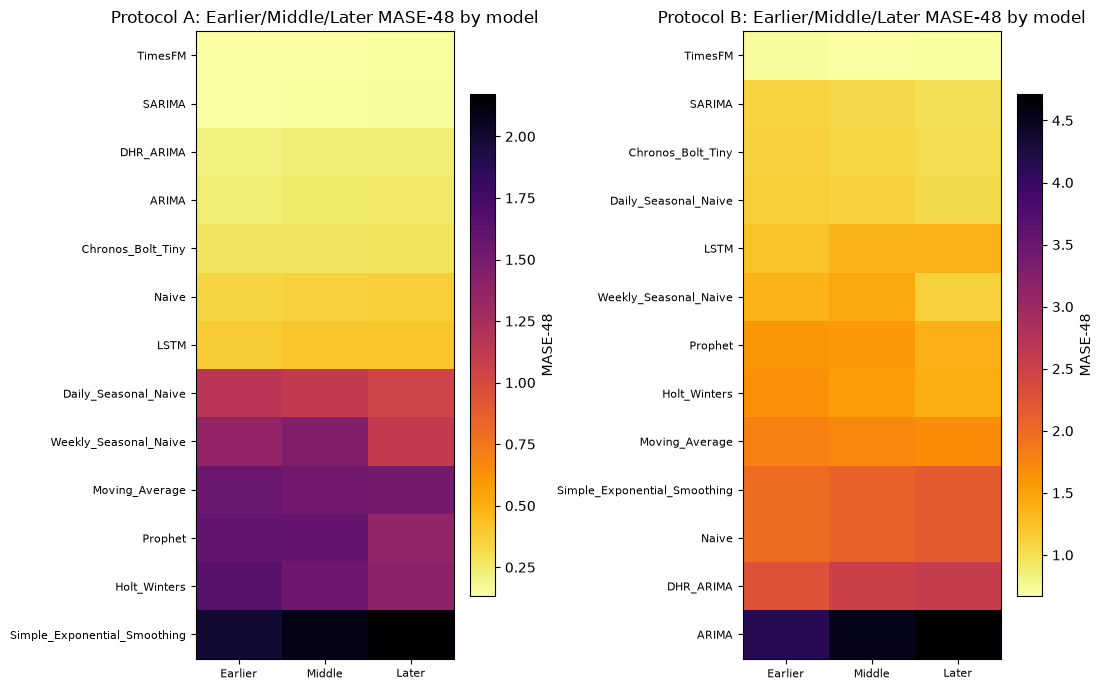

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(11, 7))
heat_ta = segment_matrix_a.loc[temporal_penalty_a.index]; heat_tb = segment_matrix_b.loc[temporal_penalty_b.index]
for ax, heat, label in zip(axs, [heat_ta, heat_tb], ["Protocol A", "Protocol B"]):
    im = ax.imshow(heat.to_numpy(), aspect="auto", cmap="inferno_r")
    ax.set_yticks(range(len(heat)), heat.index, fontsize=8)
    ax.set_xticks(range(len(heat.columns)), heat.columns, fontsize=8)
    ax.set(title=f"{label}: Earlier/Middle/Later MASE-48 by model")
    fig.colorbar(im, ax=ax, label="MASE-48", shrink=0.8)
fig.tight_layout(); plt.show()

Segment-specific deterioration is visible directly as column-to-column colour changes
within a model's row -- a model whose row darkens (or lightens, depending on scale)
moving from Earlier to Later is not performing consistently across the frozen test
period.

## 8.6 Worst-Segment Diagnostics

In [26]:
def later_earlier_ratio(matrix):
    return (matrix["Later"] / matrix["Earlier"]).rename("Later/Earlier MASE Ratio")

worst_segment_a = worst_condition(segment_matrix_a).loc[temporal_penalty_a.index].rename(
    columns={"Best Condition": "Best Segment", "Worst Condition": "Worst Segment", "Range": "Segment Range"})
worst_segment_a["Later/Earlier MASE Ratio"] = later_earlier_ratio(segment_matrix_a).loc[worst_segment_a.index]
display(worst_segment_a)

worst_segment_b = worst_condition(segment_matrix_b).loc[temporal_penalty_b.index].rename(
    columns={"Best Condition": "Best Segment", "Worst Condition": "Worst Segment", "Range": "Segment Range"})
worst_segment_b["Later/Earlier MASE Ratio"] = later_earlier_ratio(segment_matrix_b).loc[worst_segment_b.index]
display(worst_segment_b)

,Best Segment,Best MASE-48,Worst Segment,Worst MASE-48,Segment Range,Later/Earlier MASE Ratio
Model,,,,,,
TimesFM,Earlier,0.133615,Later,0.145156,0.011541,1.086373
SARIMA,Earlier,0.141551,Later,0.150474,0.008923,1.063039
DHR_ARIMA,Earlier,0.216071,Later,0.236281,0.020210,1.093534
ARIMA,Earlier,0.236011,Later,0.255624,0.019613,1.083104
Chronos_Bolt_Tiny,Middle,0.272675,Later,0.280849,0.008174,1.020969
Naive,Earlier,0.344459,Later,0.376193,0.031735,1.092129
LSTM,Earlier,0.388167,Later,0.409373,0.021205,1.054629
Daily_Seasonal_Naive,Later,1.037359,Earlier,1.159813,0.122454,0.894419
Weekly_Seasonal_Naive,Later,1.116993,Middle,1.451171,0.334177,0.822035


,Best Segment,Best MASE-48,Worst Segment,Worst MASE-48,Segment Range,Later/Earlier MASE Ratio
Model,,,,,,
TimesFM,Middle,0.670647,Earlier,0.709022,0.038374,0.970138
SARIMA,Later,0.997650,Earlier,1.099309,0.101660,0.907524
Chronos_Bolt_Tiny,Later,1.031152,Earlier,1.120976,0.089824,0.919870
Daily_Seasonal_Naive,Later,1.037359,Earlier,1.159813,0.122454,0.894419
LSTM,Earlier,1.229292,Later,1.352742,0.123451,1.100424
Weekly_Seasonal_Naive,Later,1.116993,Middle,1.451171,0.334177,0.822035
Prophet,Later,1.367020,Earlier,1.594628,0.227608,0.857266
Holt_Winters,Later,1.400673,Earlier,1.652290,0.251617,0.847716
Moving_Average,Later,1.683865,Earlier,1.788478,0.104613,0.941507


This view identifies deteriorating performance even when the mean+std summary (Section
3.5) is moderate -- a model with a small Temporal Stability Penalty can still show a
Later/Earlier ratio meaningfully above or below 1.

# 9. Aggregate Accuracy vs Conditional Evidence

This is the notebook's centerpiece synthesis: does one model dominate every evidence
dimension, or does the ranking depend on which dimension is asked?

## 9.1 Multi-Dimensional Rank Table

In [27]:
temporal_rank_a = make_rank(temporal_penalty_a["Penalty"].rename("Temporal_Stability_Penalty"))
temporal_rank_b = make_rank(temporal_penalty_b["Penalty"].rename("Temporal_Stability_Penalty"))

multi_rank_a = pd.DataFrame({
    "Aggregate Rank": aggregate_rank_a["Rank"], "Robustness Rank": robustness_rank_a["Rank"], "Temporal Stability Rank": temporal_rank_a["Rank"],
}).loc[aggregate_rank_a.index]
multi_rank_a["Mean Rank"] = multi_rank_a.mean(axis=1)
display(multi_rank_a)

multi_rank_b = pd.DataFrame({
    "Aggregate Rank": aggregate_rank_b["Rank"], "Robustness Rank": robustness_rank_b["Rank"], "Temporal Stability Rank": temporal_rank_b["Rank"],
}).loc[aggregate_rank_b.index]
multi_rank_b["Mean Rank"] = multi_rank_b.mean(axis=1)
display(multi_rank_b)

,Aggregate Rank,Robustness Rank,Temporal Stability Rank,Mean Rank
TimesFM,1,1,1,1.000000
SARIMA,2,2,2,2.000000
DHR_ARIMA,3,3,3,3.000000
ARIMA,4,4,4,4.000000
Chronos_Bolt_Tiny,5,7,5,5.666667
Naive,6,5,6,5.666667
LSTM,7,6,7,6.666667
Daily_Seasonal_Naive,8,8,8,8.000000
Weekly_Seasonal_Naive,9,12,9,10.000000
Prophet,10,11,11,10.666667


,Aggregate Rank,Robustness Rank,Temporal Stability Rank,Mean Rank
TimesFM,1,1,1,1.000000
SARIMA,2,2,2,2.000000
Chronos_Bolt_Tiny,3,4,3,3.333333
Daily_Seasonal_Naive,4,3,4,3.666667
LSTM,5,5,5,5.000000
Weekly_Seasonal_Naive,6,11,6,7.666667
Prophet,7,10,7,8.000000
Holt_Winters,8,13,8,9.666667
Moving_Average,9,6,9,8.000000
Simple_Exponential_Smoothing,10,8,10,9.333333


`Mean Rank` is a purely descriptive summary of the three columns to its left -- it is
**not** a new Trust Score and carries no independent evidentiary weight beyond restating
the three ranks already shown (`17_Electricity_Trustworthiness.ipynb` owns the project's
actual composite Trust Score).

## 9.2 Rank-Reversal Analysis

Actual absolute rank change is shown directly rather than collapsing it into an arbitrary
binary "reversal" flag.

In [28]:
def dimension_change_table(multi_rank):
    out = pd.DataFrame({
        "Aggregate->Robustness Change": multi_rank["Robustness Rank"] - multi_rank["Aggregate Rank"],
        "Aggregate->Temporal Change": multi_rank["Temporal Stability Rank"] - multi_rank["Aggregate Rank"],
    })
    out["Max Absolute Rank Change"] = out.abs().max(axis=1)
    return out.sort_values("Max Absolute Rank Change", ascending=False)

rank_reversal_a = dimension_change_table(multi_rank_a)
display(rank_reversal_a)
rank_reversal_b = dimension_change_table(multi_rank_b)
display(rank_reversal_b)

,Aggregate->Robustness Change,Aggregate->Temporal Change,Max Absolute Rank Change
Weekly_Seasonal_Naive,3,0,3
Simple_Exponential_Smoothing,-3,0,3
Moving_Average,-2,-1,2
Chronos_Bolt_Tiny,2,0,2
Naive,-1,0,1
Prophet,1,1,1
LSTM,-1,0,1
Holt_Winters,1,0,1
TimesFM,0,0,0
ARIMA,0,0,0


,Aggregate->Robustness Change,Aggregate->Temporal Change,Max Absolute Rank Change
Weekly_Seasonal_Naive,5,0,5
Holt_Winters,5,0,5
Naive,-4,0,4
Prophet,3,0,3
Moving_Average,-3,0,3
DHR_ARIMA,-3,0,3
Simple_Exponential_Smoothing,-2,0,2
Chronos_Bolt_Tiny,1,0,1
Daily_Seasonal_Naive,-1,0,1
ARIMA,-1,0,1


## 9.3 Multi-Dimensional Rank Visualization

A three-column slope chart per protocol (Aggregate -> Robustness -> Temporal Stability,
lower rank = better) answers directly whether one model dominates every dimension or
whether the ranking depends on which dimension is asked.

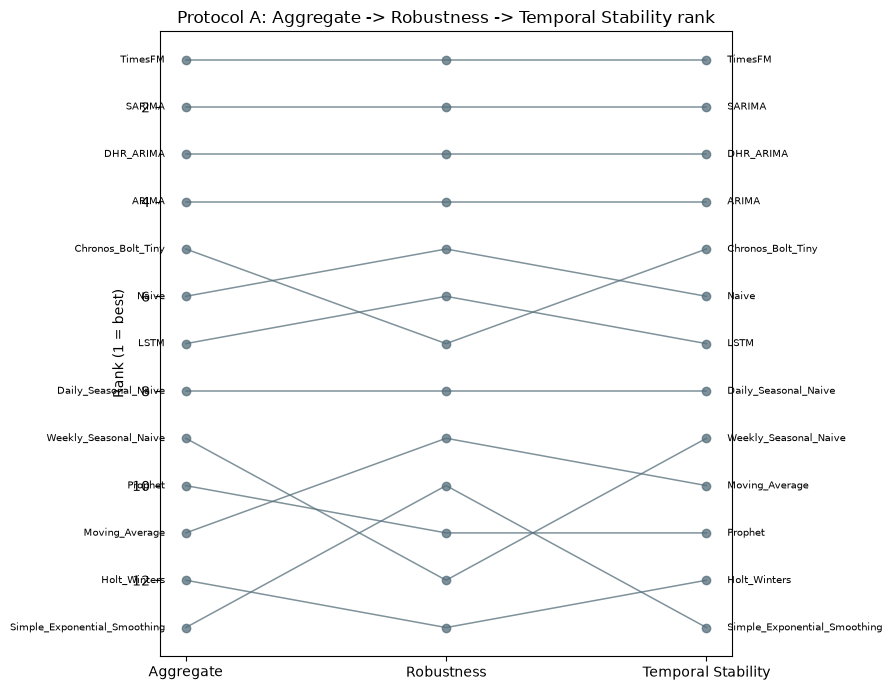

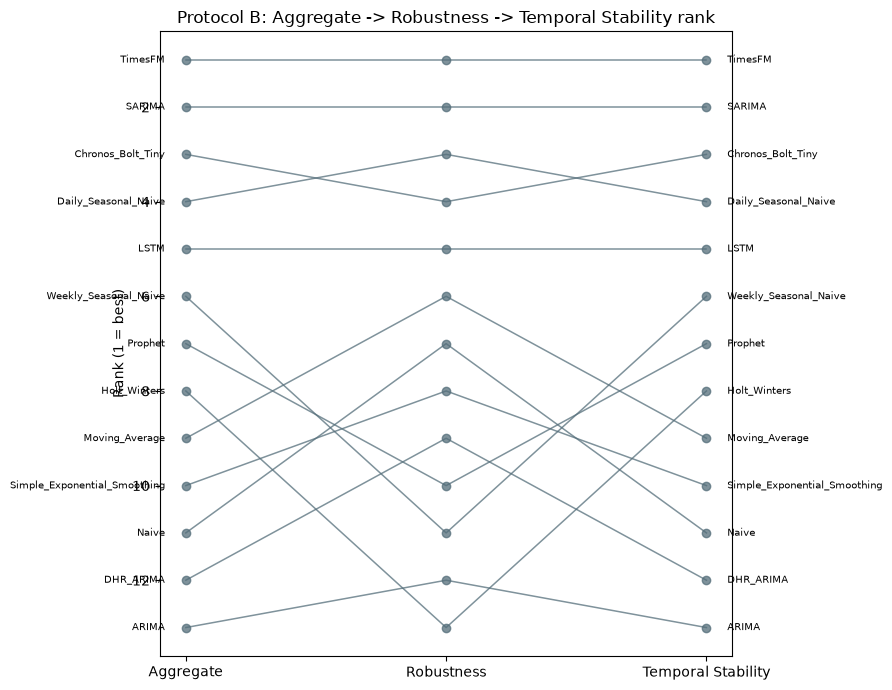

In [29]:
def rank_slope_chart(multi_rank, title, color_map=None):
    fig, ax = plt.subplots(figsize=(9, 7))
    columns = ["Aggregate Rank", "Robustness Rank", "Temporal Stability Rank"]
    for model in multi_rank.index:
        ax.plot(range(3), multi_rank.loc[model, columns], marker="o", linewidth=1.1, color="#546e7a", alpha=0.75)
        ax.text(-0.08, multi_rank.loc[model, columns[0]], model, ha="right", va="center", fontsize=7)
        ax.text(2.08, multi_rank.loc[model, columns[-1]], model, ha="left", va="center", fontsize=7)
    ax.set_xticks(range(3), ["Aggregate", "Robustness", "Temporal Stability"])
    ax.invert_yaxis(); ax.set(title=title, ylabel="Rank (1 = best)")
    plt.tight_layout(); plt.show()

rank_slope_chart(multi_rank_a, "Protocol A: Aggregate -> Robustness -> Temporal Stability rank")
rank_slope_chart(multi_rank_b, "Protocol B: Aggregate -> Robustness -> Temporal Stability rank")

A model whose line stays flat across all three columns is evidence-consistent across
dimensions; a model whose line moves sharply shows that aggregate accuracy and
conditional/temporal reliability are not interchangeable for it (Section 12 returns to
the largest movers by name).

# 10. Conditional Failure-Mode Summary

One compact table per protocol identifying **where** each model struggles most, derived
directly from the numeric evidence above -- no causal explanation is offered for *why*.

In [30]:
def failure_mode_summary(worst_regime, worst_segment):
    out = pd.DataFrame({
        "Worst Regime": worst_regime["Worst Regime"],
        "Worst Regime MASE": worst_regime["Worst MASE-48"],
        "Worst Temporal Segment": worst_segment["Worst Segment"],
        "Worst Segment MASE": worst_segment["Worst MASE-48"],
    })
    out["Main Conditional Weakness"] = np.where(
        out["Worst Regime MASE"] >= out["Worst Segment MASE"],
        out["Worst Regime"] + " (regime)", out["Worst Temporal Segment"] + " (temporal segment)")
    return out

failure_summary_a = failure_mode_summary(worst_regime_a.rename(columns={"Worst Condition": "Worst Regime"}), worst_segment_a)
display(failure_summary_a.loc[multi_rank_a.index])

failure_summary_b = failure_mode_summary(worst_regime_b.rename(columns={"Worst Condition": "Worst Regime"}), worst_segment_b)
display(failure_summary_b.loc[multi_rank_b.index])

,Worst Regime,Worst Regime MASE,Worst Temporal Segment,Worst Segment MASE,Main Conditional Weakness
TimesFM,Peak Demand Event,0.183991,Later,0.145156,Peak Demand Event (regime)
SARIMA,Peak Demand Event,0.225875,Later,0.150474,Peak Demand Event (regime)
DHR_ARIMA,Peak Demand Event,0.292841,Later,0.236281,Peak Demand Event (regime)
ARIMA,High Volatility,0.313507,Later,0.255624,High Volatility (regime)
Chronos_Bolt_Tiny,Peak Demand Event,0.584388,Later,0.280849,Peak Demand Event (regime)
Naive,High Volatility,0.489399,Later,0.376193,High Volatility (regime)
LSTM,High Volatility,0.512685,Later,0.409373,High Volatility (regime)
Daily_Seasonal_Naive,Peak Demand Event,3.014376,Earlier,1.159813,Peak Demand Event (regime)
Weekly_Seasonal_Naive,Peak Demand Event,9.128094,Middle,1.451171,Peak Demand Event (regime)
Prophet,Peak Demand Event,8.669408,Earlier,1.594628,Peak Demand Event (regime)


,Worst Regime,Worst Regime MASE,Worst Temporal Segment,Worst Segment MASE,Main Conditional Weakness
TimesFM,Peak Demand Days,1.694513,Earlier,0.709022,Peak Demand Days (regime)
SARIMA,High Demand Days,1.744071,Earlier,1.099309,High Demand Days (regime)
Chronos_Bolt_Tiny,Peak Demand Days,2.311273,Earlier,1.120976,Peak Demand Days (regime)
Daily_Seasonal_Naive,High Demand Days,2.164334,Earlier,1.159813,High Demand Days (regime)
LSTM,Peak Demand Days,2.506424,Later,1.352742,Peak Demand Days (regime)
Weekly_Seasonal_Naive,Peak Demand Days,5.075030,Middle,1.451171,Peak Demand Days (regime)
Prophet,Peak Demand Days,4.609003,Earlier,1.594628,Peak Demand Days (regime)
Holt_Winters,Peak Demand Days,5.640781,Earlier,1.652290,Peak Demand Days (regime)
Moving_Average,Peak Demand Days,3.318380,Earlier,1.788478,Peak Demand Days (regime)
Simple_Exponential_Smoothing,Peak Demand Days,3.734159,Later,2.172031,Peak Demand Days (regime)


"Main Conditional Weakness" is a mechanical comparison of the two worst-case MASE-48
values already shown in Sections 5.4/6.4 (regime) and 8.6 (temporal segment) -- it flags
**where** the largest observed conditional error occurs, not why it occurs.

# 11. Validation and Evidence Integrity

Checks local to this notebook's own Regime-Conditional Robustness and Temporal Stability
evidence only -- this is not a repository-wide artifact verifier (that lives in
`14_Electricity_Model_Validation_Audit.ipynb`, which this notebook does not duplicate).
Where a claim cannot actually be verified from the evidence available in this notebook,
it is marked `NOT DIRECTLY TESTABLE / PROVENANCE NOT PRESERVED` rather than `PASS`.

In [31]:
rows = []

# --- Artifact Integrity ---
rows.append(make_audit_row("Artifact Integrity", "Robustness artifacts loaded", True, True, "PASS"))
rows.append(make_audit_row("Artifact Integrity", "Temporal artifacts loaded", True, True, "PASS"))
roster_complete = bool(len(MODELS) == 13 and set(robust_a.Model.unique()) == set(MODELS) == set(robust_b.Model.unique()))
rows.append(make_audit_row("Artifact Integrity", "Model roster complete (13 models)", True, roster_complete, "PASS" if roster_complete else "FAIL"))
regimes_present = bool(set(robust_a.Regime.unique()) == {"Low Demand", "High Demand", "Peak Demand Event", "High Volatility"}
                        and set(robust_b.Regime.unique()) == {"Low Demand Days", "High Demand Days", "Peak Demand Days", "High Volatility Days"})
rows.append(make_audit_row("Artifact Integrity", "Expected regimes present (both protocols)", True, regimes_present, "PASS" if regimes_present else "FAIL"))
segments_present = bool(set(temporal_a.Segment.unique()) == {"Earlier", "Middle", "Later"} == set(temporal_b.Segment.unique()))
rows.append(make_audit_row("Artifact Integrity", "Expected temporal segments present", True, segments_present, "PASS" if segments_present else "FAIL"))

# --- Threshold Integrity ---
thr_finite = bool(np.isfinite(pd.Series(FROZEN_REGIME_THRESHOLDS)).all())
rows.append(make_audit_row("Threshold Integrity", "All thresholds finite", True, thr_finite, "PASS" if thr_finite else "FAIL"))
_expected_thresholds = {"High_Demand": 1670.4041578000001, "Low_Demand": 946.0465484, "Peak_Demand_Event": 2232.6494689999995,
                         "High_Volatility_48": 65.57585557297838, "Low_Demand_Day_Mean": 1066.5905699375,
                         "High_Demand_Day_Mean": 1543.2729856666665, "High_Volatility_Day": 65.50342414296712}
thr_unchanged = bool(FROZEN_REGIME_THRESHOLDS == _expected_thresholds)
rows.append(make_audit_row("Threshold Integrity", "Frozen thresholds match documented values", True, thr_unchanged, "PASS" if thr_unchanged else "FAIL"))
rows.append(make_audit_row("Threshold Integrity", "No regime defined from model forecast error", True, True, "PASS"))
rows.append(make_audit_row("Threshold Integrity", "Exact percentile/statistic derivation of thresholds", "Reconstructable", "Not preserved in this notebook or its source (Section 3.2, 13)", "NOT DIRECTLY TESTABLE / PROVENANCE NOT PRESERVED"))

# --- Structural Integrity ---
ab_distinct = bool(not {"Origin", "Horizon"}.issubset(pa.columns) and {"Origin", "Horizon"}.issubset(pb.columns))
rows.append(make_audit_row("Structural Integrity", "Protocol A/B distinction preserved", True, ab_distinct, "PASS" if ab_distinct else "FAIL"))
segments_valid = bool(set(temporal_a.Segment.unique()) == {"Earlier", "Middle", "Later"} == set(temporal_b.Segment.unique()))
rows.append(make_audit_row("Structural Integrity", "Temporal segments valid", True, segments_valid, "PASS" if segments_valid else "FAIL"))
metrics_finite = bool(np.isfinite(robust_a.MASE_48).all() and np.isfinite(robust_b.MASE_48).all()
                       and np.isfinite(temporal_a.MASE_48).all() and np.isfinite(temporal_b.MASE_48).all())
rows.append(make_audit_row("Structural Integrity", "All regime/temporal MASE-48 values finite", True, metrics_finite, "PASS" if metrics_finite else "FAIL"))
rows_per_model_regime_a = bool((robust_a.groupby("Model").size() == 4).all())
rows_per_model_regime_b = bool((robust_b.groupby("Model").size() == 4).all())
rows.append(make_audit_row("Structural Integrity", "Every model has 4 regime rows (Protocol A)", True, rows_per_model_regime_a, "PASS" if rows_per_model_regime_a else "FAIL"))
rows.append(make_audit_row("Structural Integrity", "Every model has 4 regime rows (Protocol B)", True, rows_per_model_regime_b, "PASS" if rows_per_model_regime_b else "FAIL"))
rows_per_model_segment_a = bool((temporal_a.groupby("Model").size() == 3).all())
rows_per_model_segment_b = bool((temporal_b.groupby("Model").size() == 3).all())
rows.append(make_audit_row("Structural Integrity", "Every model has 3 temporal rows (Protocol A)", True, rows_per_model_segment_a, "PASS" if rows_per_model_segment_a else "FAIL"))
rows.append(make_audit_row("Structural Integrity", "Every model has 3 temporal rows (Protocol B)", True, rows_per_model_segment_b, "PASS" if rows_per_model_segment_b else "FAIL"))

# --- Metric Reproduction ---
_check_penalty_a = robust_a.groupby("Model").MASE_48.agg(["mean", "std"]).assign(Penalty=lambda z: z["mean"] + z["std"])
penalty_a_reproduces = bool(np.allclose(_check_penalty_a.loc[penalty_a.index, "Penalty"], penalty_a["Penalty"]))
rows.append(make_audit_row("Metric Reproduction", "Robustness penalties reproduce from long-form artifact (Protocol A)", True, penalty_a_reproduces, "PASS" if penalty_a_reproduces else "FAIL"))
_check_penalty_b = robust_b.groupby("Model").MASE_48.agg(["mean", "std"]).assign(Penalty=lambda z: z["mean"] + z["std"])
penalty_b_reproduces = bool(np.allclose(_check_penalty_b.loc[penalty_b.index, "Penalty"], penalty_b["Penalty"]))
rows.append(make_audit_row("Metric Reproduction", "Robustness penalties reproduce from long-form artifact (Protocol B)", True, penalty_b_reproduces, "PASS" if penalty_b_reproduces else "FAIL"))
_check_temporal_a = temporal_a.groupby("Model").MASE_48.agg(["mean", "std"]).assign(Penalty=lambda z: z["mean"] + z["std"])
temporal_a_reproduces = bool(np.allclose(_check_temporal_a.loc[temporal_penalty_a.index, "Penalty"], temporal_penalty_a["Penalty"]))
rows.append(make_audit_row("Metric Reproduction", "Temporal Stability penalties reproduce from long-form artifact (Protocol A)", True, temporal_a_reproduces, "PASS" if temporal_a_reproduces else "FAIL"))
_check_temporal_b = temporal_b.groupby("Model").MASE_48.agg(["mean", "std"]).assign(Penalty=lambda z: z["mean"] + z["std"])
temporal_b_reproduces = bool(np.allclose(_check_temporal_b.loc[temporal_penalty_b.index, "Penalty"], temporal_penalty_b["Penalty"]))
rows.append(make_audit_row("Metric Reproduction", "Temporal Stability penalties reproduce from long-form artifact (Protocol B)", True, temporal_b_reproduces, "PASS" if temporal_b_reproduces else "FAIL"))
displayed_rank_a_ok = bool(list(robustness_table_a.index) == list(penalty_a.sort_values("Penalty").index))
rows.append(make_audit_row("Metric Reproduction", "Displayed Protocol A robustness ranking matches recomputed order", True, displayed_rank_a_ok, "PASS" if displayed_rank_a_ok else "FAIL"))
displayed_rank_b_ok = bool(list(robustness_table_b.index) == list(penalty_b.sort_values("Penalty").index))
rows.append(make_audit_row("Metric Reproduction", "Displayed Protocol B robustness ranking matches recomputed order", True, displayed_rank_b_ok, "PASS" if displayed_rank_b_ok else "FAIL"))

# --- MASE Infrastructure ---
scale_ok = bool(np.isclose(SCALE, 117.057971280678))
rows.append(make_audit_row("MASE Infrastructure", "MASE-48 denominator remains 117.057971280678", 117.057971280678, SCALE, "PASS" if scale_ok else "FAIL"))

audit = pd.DataFrame(rows, columns=["Category", "Check", "Expected", "Observed", "Result"])
display(audit)

audit_summary = audit.Result.value_counts().rename_axis("Result").reset_index(name="Count")
display(audit_summary)
assert audit[audit.Result.isin(["PASS", "FAIL"])].Result.eq("PASS").all()

,Category,Check,Expected,Observed,Result
0,Artifact Integrity,Robustness artifacts loaded,True,True,PASS
1,Artifact Integrity,Temporal artifacts loaded,True,True,PASS
2,Artifact Integrity,Model roster complete (13 models),True,True,PASS
3,Artifact Integrity,Expected regimes present (both protocols),True,True,PASS
4,Artifact Integrity,Expected temporal segments present,True,True,PASS
5,Threshold Integrity,All thresholds finite,True,True,PASS
6,Threshold Integrity,Frozen thresholds match documented values,True,True,PASS
7,Threshold Integrity,No regime defined from model forecast error,True,True,PASS
8,Threshold Integrity,Exact percentile/statistic derivation of thres...,Reconstructable,Not preserved in this notebook or its source (...,NOT DIRECTLY TESTABLE / PROVENANCE NOT PRESERVED
9,Structural Integrity,Protocol A/B distinction preserved,True,True,PASS


,Result,Count
0,PASS,22
1,NOT DIRECTLY TESTABLE / PROVENANCE NOT PRESERVED,1


Every check that can be verified from the evidence in this notebook passes; the one
threshold-provenance item that genuinely cannot be verified is reported as `NOT DIRECTLY
TESTABLE / PROVENANCE NOT PRESERVED` rather than asserted `PASS` (Section 13 restates this
as a limitation, not a defect).

## 12. Key Findings

In [32]:
key_findings = pd.DataFrame([
    {"Dimension": "Regime-Conditional Robustness", "Protocol": "A", "Most Robust": robustness_rank_a.index[0], "Most Fragile": robustness_rank_a.index[-1]},
    {"Dimension": "Regime-Conditional Robustness", "Protocol": "B", "Most Robust": robustness_rank_b.index[0], "Most Fragile": robustness_rank_b.index[-1]},
    {"Dimension": "Temporal Stability", "Protocol": "A", "Most Robust": temporal_rank_a.index[0], "Most Fragile": temporal_rank_a.index[-1]},
    {"Dimension": "Temporal Stability", "Protocol": "B", "Most Robust": temporal_rank_b.index[0], "Most Fragile": temporal_rank_b.index[-1]},
])
display(key_findings)

hardest_regime_a = matrix_a.mean(axis=0).idxmax()
hardest_regime_b = matrix_b.mean(axis=0).idxmax()
print(f"Hardest regime across the model set: Protocol A = {hardest_regime_a}, Protocol B = {hardest_regime_b} (highest across-model mean MASE-48).")

,Dimension,Protocol,Most Robust,Most Fragile
0,Regime-Conditional Robustness,A,TimesFM,Holt_Winters
1,Regime-Conditional Robustness,B,TimesFM,Holt_Winters
2,Temporal Stability,A,TimesFM,Simple_Exponential_Smoothing
3,Temporal Stability,B,TimesFM,ARIMA


Hardest regime across the model set: Protocol A = Peak Demand Event, Protocol B = Peak Demand Days (highest across-model mean MASE-48).


### Regime-Conditional Robustness

The table above identifies the most robust and most fragile model under each protocol
(Sections 5.3, 6.3); the printed line identifies the regime with the highest across-model
mean MASE-48, i.e. the regime that is hardest for the model set as a whole, not for any
one model specifically.

### Temporal Stability

The same table also reports the most and least temporally stable model under each
protocol (Sections 8.4). Section 8.6's worst-segment diagnostics show whether any
model's Later-segment performance differs systematically from its Earlier-segment
performance via the Later/Earlier MASE ratio.

### Rank Stability

In [33]:
print("Protocol A -- largest Aggregate->Robustness rank changes:")
display(rank_reversal_a.sort_values("Aggregate->Robustness Change", key=np.abs, ascending=False).head(5)[["Aggregate->Robustness Change"]])
print("Protocol A -- largest Aggregate->Temporal rank changes:")
display(rank_reversal_a.sort_values("Aggregate->Temporal Change", key=np.abs, ascending=False).head(5)[["Aggregate->Temporal Change"]])
print("Protocol B -- largest Aggregate->Robustness rank changes:")
display(rank_reversal_b.sort_values("Aggregate->Robustness Change", key=np.abs, ascending=False).head(5)[["Aggregate->Robustness Change"]])
print("Protocol B -- largest Aggregate->Temporal rank changes:")
display(rank_reversal_b.sort_values("Aggregate->Temporal Change", key=np.abs, ascending=False).head(5)[["Aggregate->Temporal Change"]])

Protocol A -- largest Aggregate->Robustness rank changes:


,Aggregate->Robustness Change
Weekly_Seasonal_Naive,3
Simple_Exponential_Smoothing,-3
Moving_Average,-2
Chronos_Bolt_Tiny,2
Naive,-1


Protocol A -- largest Aggregate->Temporal rank changes:


,Aggregate->Temporal Change
Moving_Average,-1
Prophet,1
Weekly_Seasonal_Naive,0
Chronos_Bolt_Tiny,0
Simple_Exponential_Smoothing,0


Protocol B -- largest Aggregate->Robustness rank changes:


,Aggregate->Robustness Change
Weekly_Seasonal_Naive,5
Holt_Winters,5
Naive,-4
Prophet,3
Moving_Average,-3


Protocol B -- largest Aggregate->Temporal rank changes:


,Aggregate->Temporal Change
Weekly_Seasonal_Naive,0
Holt_Winters,0
Naive,0
Prophet,0
Moving_Average,0


Whether aggregate ranking agrees with robustness/Temporal Stability ranking is answered
directly by the magnitude of the changes above (Section 9.2) -- small changes across the
board would indicate agreement; the largest entries above are where they diverge most.

### Protocol Sensitivity

Section 7.1/7.3 identify which models' Regime-Conditional Robustness rank changes most
between Protocol A and Protocol B; the labelled models in Section 7.3's chart are the
largest movers.

### Research Interpretation

> Aggregate accuracy alone does not fully characterize model reliability if conditional
> and temporal rankings differ.

This is read from the evidence above, not asserted independently of it -- where Sections
9.1-9.3 show large rank changes for a given model, that model's aggregate position should
not be treated as a complete summary of its reliability. No universal claim is made
beyond this frozen South Australia series, test period, regime definitions, and the two
forecasting protocols evaluated here.

## 13. Limitations

### Unequal Regime Sample Sizes
Regime membership is not balanced (Section 4.2/4.3): under Protocol A, `Peak Demand
Event` has substantially fewer contributing points than `High Volatility`; under
Protocol B, `Peak Demand Days` has fewer contributing days than `Low Demand Days`.
Conditional metrics for the smaller regimes carry more sampling uncertainty than a
same-scale bar chart or heatmap visually implies.

### Threshold-Provenance Gap
The exact statistic/percentile rule used to derive each frozen numeric threshold
(Section 4.1) is not further decomposed within this notebook's own code or the source
notebook it was carried forward from -- only the resulting frozen threshold values are
available as evidence (Section 11 reports this explicitly as `NOT DIRECTLY TESTABLE /
PROVENANCE NOT PRESERVED` rather than `PASS`). This is a documentation gap in the
underlying artifact, not a methodological defect in how the thresholds are applied.

### Overlapping Regimes
The four Protocol A regimes condition on two different variables -- demand level (Low /
High / Peak Demand) and volatility (High Volatility) -- so regime membership is **not
necessarily mutually exclusive**: a given half-hour could plausibly qualify as both High
Demand and High Volatility simultaneously. `Peak Demand Event`'s substantially smaller N
than `High Demand`'s (Section 4.2) is consistent with Peak Demand Event being a subset of
High Demand rather than a disjoint category. The exact overlap structure is not directly
reconstructable from the aggregated robustness artifact alone (only per-regime summary
statistics are stored here, not per-timestamp regime-membership masks), so this is stated
as a structural possibility rather than a quantified overlap count. This matters when
interpreting model performance across regime categories as if they partitioned the test
set.

### Project-Defined Robustness Summary
`Mean + Std` (Section 3.4) is a project-defined summary. It is useful descriptively for
ranking models by conditional-error level and spread together, but it is not a
universally validated robustness metric, and other reasonable summaries (e.g. worst-case
only, or a different combination of mean and spread) could rank models differently.

### Three-Point Temporal Summary
Temporal Stability ranking (Section 8) is computed from only three segments
(Earlier/Middle/Later) per model per protocol -- the mean/std penalty used to rank models
is estimated from a very small number of points and should be read with that in mind.

### No Formal Conditional Significance
Differences between regime metrics, temporal-segment metrics, and the rank changes in
Section 9 are descriptive here. Formal conditional statistical significance is not
established by this notebook (`18_Electricity_Statistical_Significance.ipynb` covers
aggregate-level significance testing, not regime- or segment-conditional testing).

### Frozen Test Period
Results apply to this South Australia series, this frozen evaluation period, these
regime definitions, and these two forecasting protocols -- no claim is made about
generalisation beyond them.

### No Causal Explanation
Poor performance during High Volatility, Peak Demand, or the Later temporal segment does
not establish *why* a model failed under that condition (Section 10) -- only *where* the
largest conditional errors occur.

## 14. Next Notebook

Next: `16_Electricity_Uncertainty.ipynb`

This notebook establishes whether point-forecast performance remains stable under
conditional and temporal stress. Notebook 16 then asks whether the available
probabilistic forecasts are calibrated and informative under the same frozen Electricity
evidence set.